<a href="https://colab.research.google.com/github/Koji-Accounting-Tech/D365-Finance-Data-Validator/blob/main/D365_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Excelファイルの読み込み
df = pd.read_excel('test_data.xlsx')

# 2. データの先頭5行を表示して中身を確認
print("--- データの先頭5行 ---")
display(df.head())

# 3. 基本的な統計量（件数、合計、平均など）を表示
print("\n--- データの統計情報 ---")
display(df.describe())

--- データの先頭5行 ---


,伝票番号,日付,勘定科目コード,借方金額,貸方金額,摘要
0,1,2026-04-01,100501,100000,100000,備品
1,2,2026-04-01,100601,200000,200000,買掛金支払
2,3,2026-04-01,100701,300000,300000,売掛金入金
3,4,2026-04-02,100802,400000,400000,減価償却・設備
4,5,2026-04-02,200101,500000,500000,売上



--- データの統計情報 ---


,伝票番号,日付,勘定科目コード,借方金額,貸方金額
count,5.000000,5,5.000000,5.000000,5.000000
mean,3.000000,2026-04-01 09:36:00,120541.200000,300000.000000,300000.000000
min,1.000000,2026-04-01 00:00:00,100501.000000,100000.000000,100000.000000
25%,2.000000,2026-04-01 00:00:00,100601.000000,200000.000000,200000.000000
50%,3.000000,2026-04-01 00:00:00,100701.000000,300000.000000,300000.000000
75%,4.000000,2026-04-02 00:00:00,100802.000000,400000.000000,400000.000000
max,5.000000,2026-04-02 00:00:00,200101.000000,500000.000000,500000.000000
std,1.581139,NaN,44475.421642,158113.883008,158113.883008


--- 短時間大量操作（バースト）検知レポート ---
⚠️ 警告: 短時間に大量の操作を行ったユーザーが 1 名見つかりました。


,作成者,作成日時,1分間内の件数
6,UserC,2024-04-10 17:05:40,5.0


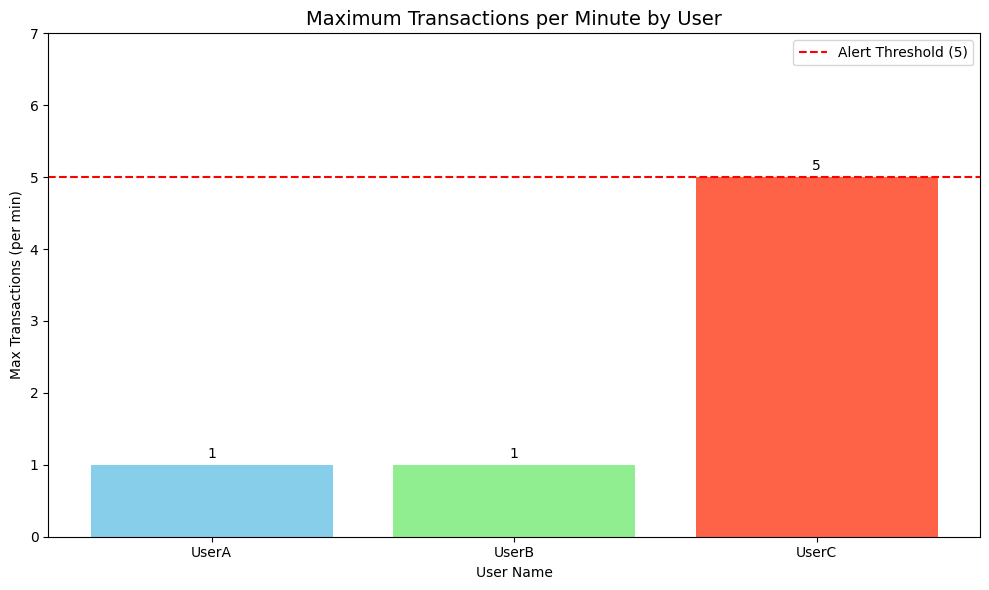

In [2]:
import pandas as pd

# 1. 作成ログデータ
# UserC が短時間（17:05台）に連続して作成している想定
log_data = {
    '伝票番号': ['V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207'],
    '作成日時': [
        '2024-04-10 17:00:00',
        '2024-04-10 17:01:00',
        '2024-04-10 17:05:00', # UserC バースト開始
        '2024-04-10 17:05:10', # UserC
        '2024-04-10 17:05:20', # UserC
        '2024-04-10 17:05:30', # UserC
        '2024-04-10 17:05:40'  # UserC
    ],
    '作成者': ['UserA', 'UserB', 'UserC', 'UserC', 'UserC', 'UserC', 'UserC']
}
df_logs = pd.DataFrame(log_data)
df_logs['作成日時'] = pd.to_datetime(df_logs['作成日時'])

# 2. ユーザーごとに1分間のウィンドウで件数をカウントする
# ※ '1min' という指定で1分間の幅を見ます
df_logs = df_logs.sort_values('作成日時') # 時間順に並べ替え
df_logs = df_logs.set_index('作成日時')    # 時間をインデックス（索引）にする

# ユーザーごとにグループ化し、1分間（Rolling 1min）の件数を算出
burst_check = df_logs.groupby('作成者')['伝票番号'].rolling('1min').count()
burst_check = burst_check.reset_index()
burst_check.columns = ['作成者', '作成日時', '1分間内の件数']

# 3. 異常判定（1分間に5件以上を異常とする）
alert_threshold = 5
alerts = burst_check[burst_check['1分間内の件数'] >= alert_threshold]

print("--- 短時間大量操作（バースト）検知レポート ---")
if len(alerts) > 0:
    print(f"⚠️ 警告: 短時間に大量の操作を行ったユーザーが {len(alerts['作成者'].unique())} 名見つかりました。")
    display(alerts)
else:
    print("✅ 全てのユーザーの操作頻度は正常範囲内です。")

import matplotlib.pyplot as plt

# 4. ユーザーごとの「最大同時操作数」を抽出
# 各作成者の中で、最も高かった「1分間内の件数」を取得します
user_max_burst = burst_check.groupby('作成者')['1分間内の件数'].max().reset_index()

# 5. データの準備（英語表記に変換してグローバル対応）
# 日本語が含まれる場合は英語にマップします
user_labels = user_max_burst['作成者']
max_values = user_max_burst['1分間内の件数']

# 6. グラフの作成
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(user_labels, max_values, color=['skyblue', 'lightgreen', 'tomato'])

# 7. タイトルとラベルの設定（英語）
ax.set_title('Maximum Transactions per Minute by User', fontsize=14)
ax.set_xlabel('User Name')
ax.set_ylabel('Max Transactions (per min)')
ax.set_ylim(0, max(max_values) + 2) # 上部に少し余白を作る

# 8. 数値ラベルを棒の上に表示
ax.bar_label(bars, padding=3, fmt='%.0f')

# 異常値（しきい値5）に水平線を引く（エスカレーションエンジニアらしい演出）
ax.axhline(y=5, color='red', linestyle='--', label='Alert Threshold (5)')
ax.legend()

plt.tight_layout()
plt.show()

--- 予算対実績 差異分析レポート ---


,部門,予算額,実績額,差異,消化率(%),ステータス
0,営業部,5000000,4800000,200000,96.0,✅ 正常
1,マーケティング部,3000000,3100000,-100000,103.3,✅ 正常
2,開発部,8000000,9500000,-1500000,118.8,⚠️ 超過(Over)
3,人事部,1500000,600000,900000,40.0,ℹ️ 未消化(Under)
4,総務部,1000000,1050000,-50000,105.0,✅ 正常



--- 要確認部門リスト ---


,部門,予算額,実績額,差異,消化率(%),ステータス
2,開発部,8000000,9500000,-1500000,118.8,⚠️ 超過(Over)
3,人事部,1500000,600000,900000,40.0,ℹ️ 未消化(Under)


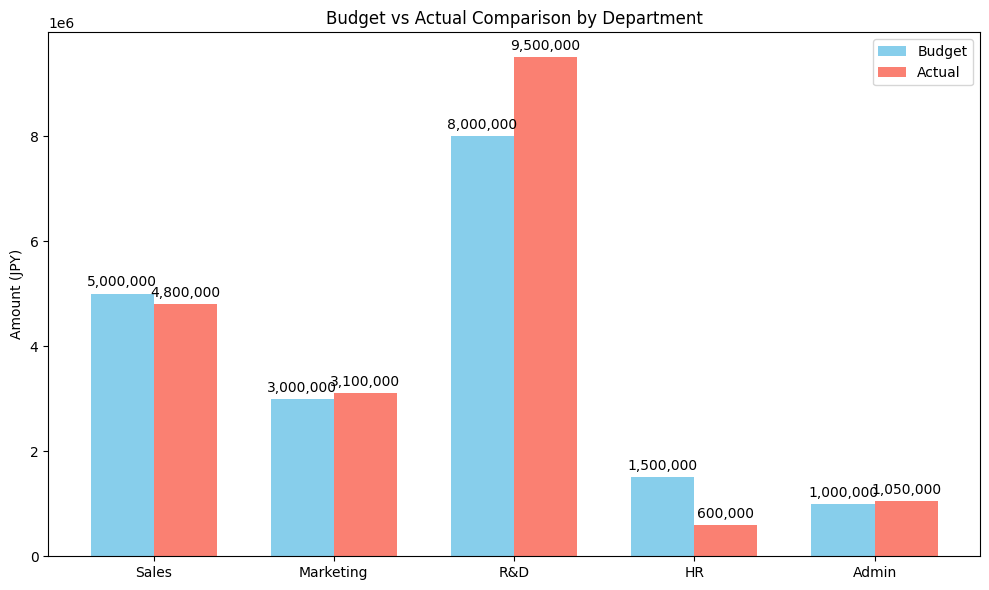

In [ ]:
import pandas as pd

# 1. 予算データ (Budget)
budget_data = {
    '部門': ['営業部', 'マーケティング部', '開発部', '人事部', '総務部'],
    '予算額': [5000000, 3000000, 8000000, 1500000, 1000000]
}
df_budget = pd.DataFrame(budget_data)

# 2. 実績データ (Actual)
# ※ 開発部が予算超過、人事部が極端に未消化の想定
actual_data = {
    '部門': ['営業部', 'マーケティング部', '開発部', '人事部', '総務部'],
    '実績額': [4800000, 3100000, 9500000, 600000, 1050000]
}
df_actual = pd.DataFrame(actual_data)

# 3. 予実比較の統合
df_vansa = pd.merge(df_budget, df_actual, on='部門')

# 4. 差異と消化率の計算
df_vansa['差異'] = df_vansa['予算額'] - df_vansa['実績額']
df_vansa['消化率(%)'] = (df_vansa['実績額'] / df_vansa['予算額'] * 100).round(1)

# 5. 異常値（Alert）の判定ロジック
# 消化率が110%以上、または50%以下を異常とする
def judge_alert(percent):
    if percent >= 110:
        return "⚠️ 超過(Over)"
    elif percent <= 50:
        return "ℹ️ 未消化(Under)"
    else:
        return "✅ 正常"

df_vansa['ステータス'] = df_vansa['消化率(%)'].apply(judge_alert)

print("--- 予算対実績 差異分析レポート ---")
display(df_vansa)

# 6. アラート対象のみ抽出
alerts = df_vansa[df_vansa['ステータス'] != "✅ 正常"]
print("\n--- 要確認部門リスト ---")
display(alerts)

import matplotlib.pyplot as plt
import numpy as np

# 日本語フォントの設定（Colabで日本語を表示するための簡易設定）
plt.rcParams['font.family'] = 'sans-serif'

# 7. データの準備（英語にマッピング）
# 日本語の部門名を英語に変換して表示用にする
dept_map = {
    '営業部': 'Sales',
    'マーケティング部': 'Marketing',
    '開発部': 'R&D',
    '人事部': 'HR',
    '総務部': 'Admin'
}
labels = df_vansa['部門'].map(dept_map)
budget = df_vansa['予算額']
actual = df_vansa['実績額']

x = np.arange(len(labels))
width = 0.35

# 8. グラフの作成
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, budget, width, label='Budget', color='skyblue')
rects2 = ax.bar(x + width/2, actual, width, label='Actual', color='salmon')

# 8. ラベルやタイトルの設定（英語）
ax.set_ylabel('Amount (JPY)')
ax.set_title('Budget vs Actual Comparison by Department')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# 9. 棒の上に数値を表示する（オプション）
ax.bar_label(rects1, padding=3, fmt='{:,.0f}')
ax.bar_label(rects2, padding=3, fmt='{:,.0f}')

fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. 大量の仕訳データ（模擬データ）
# ※ V003 と V005 が、日付・科目・金額がすべて同じ「重複」の疑いがあるデータ
journal_data = {
    '伝票番号': ['V001', 'V002', 'V003', 'V004', 'V005'],
    '取引日': ['2024-04-01', '2024-04-02', '2024-04-03', '2024-04-04', '2024-04-03'],
    '勘定科目': ['交際費', '消耗品費', '支払手数料', '通信費', '支払手数料'],
    '金額': [5000, 2000, 15000, 3000, 15000],
    '作成者': ['UserA', 'UserB', 'UserA', 'UserC', 'UserA']
}
df_journal = pd.DataFrame(journal_data)

# 2. 重複チェックロジック
# 「取引日」「勘定科目」「金額」の3つが一致するものを探す
# keep=False を指定すると、重複している行すべてを抽出できる
duplicates = df_journal[df_journal.duplicated(subset=['取引日', '勘定科目', '金額'], keep=False)]

print("--- 重複仕訳（二重計上）の疑いがあるデータ ---")
if len(duplicates) > 0:
    print(f"⚠️ 警告: 重複の可能性がある仕訳が {len(duplicates)} 件見つかりました。")
    display(duplicates.sort_values(by=['取引日', '金額']))
else:
    print("✅ 重複した仕訳は見つかりませんでした。")

# 3. (応用) 重複の「理由」を推測するヒント
# 同じ作成者が短時間に操作した可能性などを分析

--- 重複仕訳（二重計上）の疑いがあるデータ ---
⚠️ 警告: 重複の可能性がある仕訳が 2 件見つかりました。


,伝票番号,取引日,勘定科目,金額,作成者
2,V003,2024-04-03,支払手数料,15000,UserA
4,V005,2024-04-03,支払手数料,15000,UserA


In [ ]:
import pandas as pd

# 1. 作成日時を含む仕訳データ
audit_data = {
    '伝票番号': ['V101', 'V102', 'V103', 'V104', 'V105'],
    '作成日時': [
        '2024-04-01 10:00:00', # 月曜 10時 (正常)
        '2024-04-06 14:00:00', # 土曜 14時 (休日)
        '2024-04-03 23:30:00', # 水曜 23時半 (深夜)
        '2024-04-04 09:15:00', # 木曜 09時 (正常)
        '2024-04-07 02:00:00'  # 日曜 02時 (休日かつ深夜)
    ],
    '金額': [50000, 120000, 3000, 45000, 800000],
    '作成者': ['UserA', 'UserB', 'UserC', 'UserA', 'UserB']
}
df_audit = pd.DataFrame(audit_data)

# 2. 文字列を日付型（datetime）に変換
df_audit['作成日時'] = pd.to_datetime(df_audit['作成日時'])

# 3. 曜日（0=月, 6=日）と時間（0-23）を抽出
df_audit['曜日'] = df_audit['作成日時'].dt.weekday
df_audit['時間'] = df_audit['作成日時'].dt.hour

# 4. 異常判定ロジック
# 条件1: 曜日が土日 (5 または 6)
# 条件2: 時間が 22時以降 または 5時未満
is_weekend = df_audit['曜日'] >= 5
is_late_night = (df_audit['時間'] >= 22) | (df_audit['時間'] < 5)

# いずれかの条件に当てはまるものを抽出
suspicious_logs = df_audit[is_weekend | is_late_night].copy()

# 表示用に曜日の名前を追加
weekday_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
suspicious_logs['曜日名'] = suspicious_logs['曜日'].map(weekday_names)

print("--- 不自然な時間帯・曜日の仕訳ログ ---")
if len(suspicious_logs) > 0:
    print(f"⚠️ 警告: 内部統制上の確認が必要な仕訳が {len(suspicious_logs)} 件あります。")
    display(suspicious_logs[['伝票番号', '作成日時', '曜日名', '時間', '作成者', '金額']])
else:
    print("✅ すべての仕訳は標準的な営業時間内に作成されています。")

--- 不自然な時間帯・曜日の仕訳ログ ---
⚠️ 警告: 内部統制上の確認が必要な仕訳が 3 件あります。


,伝票番号,作成日時,曜日名,時間,作成者,金額
1,V102,2024-04-06 14:00:00,Sat,14,UserB,120000
2,V103,2024-04-03 23:30:00,Wed,23,UserC,3000
4,V105,2024-04-07 02:00:00,Sun,2,UserB,800000


In [ ]:
import pandas as pd

# 1. 各法人の個別試算表（TB）データ
# 1. 親会社のデータ
parent_data = {
    '勘定科目': ['売上高', '売上高', '売上原価', '一般管理費'],
    '金額': [-4000000, -1000000, 3000000, 1000000], # 子会社分を-100万にする
    '相手先': ['外部企業', '子会社A', '外部企業', '外部企業']
}
df_parent = pd.DataFrame(parent_data)

# 子会社A
sub_data = {
    '勘定科目': ['売上高', '売上原価', '一般管理費', '買掛金'],
    '金額': [-2000000, 1000000, 500000, -1500000],
    '相手先': ['外部企業', '親会社', '外部企業', '親会社']
}

df_parent = pd.DataFrame(parent_data)
df_sub = pd.DataFrame(sub_data)

# 2. 単純合算（連結の第一歩）
df_combined = pd.concat([df_parent, df_sub]).groupby('勘定科目')['金額'].sum().reset_index()
df_combined.rename(columns={'金額': '合算金額'}, inplace=True)

# 3. 内部取引消去ロジック
# 親会社の「売上（対子会社）」と子会社の「売上原価（対親会社）」を特定して消去
# elimination_amount = 1000000 # 相殺額
# ① データを手入力せず、親会社の「対子会社売上」から自動計算する
intercompany_sales = df_parent[
    (df_parent['勘定科目'] == '売上高') & (df_parent['相手先'] == '子会社A')
]['金額'].sum()

# 売上はマイナス表記なので、絶対値（abs）にして消去額とする
elimination_amount = abs(intercompany_sales)

print(f"自動抽出された相殺額: {elimination_amount:,}円")

# 消去仕訳のデータフレーム作成
elim_data = [
    {'勘定科目': '売上高', '消去額': elimination_amount},     # 売上のマイナス（貸方）を消すためにプラス
    {'勘定科目': '売上原価', '消去額': -elimination_amount} # 原価のプラス（借方）を消すためにマイナス
]
df_elim = pd.DataFrame(elim_data)

# 4. 最終連結財務諸表の作成
df_final = pd.merge(df_combined, df_elim, on='勘定科目', how='left').fillna(0)
df_final['連結金額'] = df_final['合算金額'] + df_final['消去額']

print("--- 連結決算ワークシート ---")
display(df_final[['勘定科目', '合算金額', '消去額', '連結金額']])

自動抽出された相殺額: 1,000,000円
--- 連結決算ワークシート ---


,勘定科目,合算金額,消去額,連結金額
0,一般管理費,1500000,0.0,1500000.0
1,売上原価,4000000,-1000000.0,3000000.0
2,売上高,-7000000,1000000.0,-6000000.0
3,買掛金,-1500000,0.0,-1500000.0


In [ ]:
import pandas as pd

# 1. 取引データ（請求時と支払時のデータ）
# ※ 伝票 FX003 は、入力された損益額が間違っている想定（計算チェック用）
exchange_data = {
    '取引ID': ['FX001', 'FX002', 'FX003'],
    '外貨額_USD': [100.0, 250.0, 150.0],
    '請求時レート': [150.0, 151.0, 149.0],
    '支払時レート': [155.0, 148.0, 152.0],
    '入力済為替損益': [-500, 750, -100] # FX003は本来 -450のはず
}
df_fx = pd.DataFrame(exchange_data)

# 2. 為替差損益の計算ロジック
# 計算式: 外貨額 * (請求時レート - 支払時レート)
# ※ 正数なら「益」、負数なら「損」
df_fx['理論上の為替損益'] = (
    df_fx['外貨額_USD'] * (df_fx['請求時レート'] - df_fx['支払時レート'])
).astype(int)

# 3. 誤差の検知
df_fx['計算誤差'] = df_fx['入力済為替損益'] - df_fx['理論上の為替損益']
error_fx = df_fx[df_fx['計算誤差'] != 0]

print("--- 為替差損益（実現損益）検証レポート ---")
if len(error_fx) > 0:
    print(f"⚠️ 警告: 為替差損益の計算不整合が {len(error_fx)} 件あります。")
    display(error_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '入力済為替損益', '計算誤差']])
else:
    print("✅ すべての為替差損益が正しく計上されています。")

--- 為替差損益（実現損益）検証レポート ---
⚠️ 警告: 為替差損益の計算不整合が 1 件あります。


,取引ID,外貨額_USD,理論上の為替損益,入力済為替損益,計算誤差
2,FX003,150.0,-450,-100,350


In [ ]:
import pandas as pd

# 1. 判定用の関数を定義
def judge_gain_loss(amount):
    if amount > 0:
        return "為替差益"
    elif amount < 0:
        return "為替差損"
    else:
        return "差損益なし"

# 2. 取引データ（請求時と支払時のデータ）
# ※ 伝票 FX003 は、入力された損益額が間違っている想定（計算チェック用）
exchange_data = {
    '取引ID': ['FX001', 'FX002', 'FX003'],
    '外貨額_USD': [100.0, 250.0, 150.0],
    '請求時レート': [150.0, 151.0, 149.0],
    '支払時レート': [155.0, 148.0, 152.0],
    '入力済為替損益': [-500, 750, -100] # FX003は本来 -450のはず
}
df_fx = pd.DataFrame(exchange_data)

# 2. 為替差損益の計算ロジック
# 計算式: 外貨額 * (請求時レート - 支払時レート)
# ※ 正数なら「益」、負数なら「損」
df_fx['理論上の為替損益'] = (
    df_fx['外貨額_USD'] * (df_fx['請求時レート'] - df_fx['支払時レート'])
).astype(int)

# 3. 誤差の検知
df_fx['計算誤差'] = df_fx['入力済為替損益'] - df_fx['理論上の為替損益']
error_fx = df_fx[df_fx['計算誤差'] != 0]

print("--- 為替差損益（実現損益）検証レポート ---")
if len(error_fx) > 0:
    print(f"⚠️ 警告: 為替差損益の計算不整合が {len(error_fx)} 件あります。")
    display(error_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '入力済為替損益', '計算誤差']])
else:
    print("✅ すべての為替差損益が正しく計上されています。")

# 4. apply関数を使って「理論上の為替損益」列から判定結果を生成
df_fx['判定ラベル'] = df_fx['理論上の為替損益'].apply(judge_gain_loss)

# 5. 結果の表示
print("--- 為替差損益 判定レポート ---")
display(df_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '判定ラベル']])

# 6. (応用) 為替差損（マイナス）のデータだけを抽出して合計を出す
total_loss = df_fx[df_fx['判定ラベル'] == "為替差損"]['理論上の為替損益'].sum()
print(f"\n今回の総為替差損額: {abs(total_loss):,}円")

--- 為替差損益（実現損益）検証レポート ---
⚠️ 警告: 為替差損益の計算不整合が 1 件あります。


,取引ID,外貨額_USD,理論上の為替損益,入力済為替損益,計算誤差
2,FX003,150.0,-450,-100,350


--- 為替差損益 判定レポート ---


,取引ID,外貨額_USD,理論上の為替損益,判定ラベル
0,FX001,100.0,-500,為替差損
1,FX002,250.0,750,為替差益
2,FX003,150.0,-450,為替差損



今回の総為替差損額: 950円


In [ ]:
import pandas as pd

# 1. 判定用の関数を定義
def judge_gain_loss(amount):
    if amount > 0:
        return "為替差益"
    elif amount < 0:
        return "為替差損"
    else:
        return "差損益なし"

# 2. 取引データ（請求時と支払時のデータ）
# ※ 伝票 FX003 は、入力された損益額が間違っている想定（計算チェック用）
exchange_data = {
    '取引ID': ['FX001', 'FX002', 'FX003'],
    '外貨額_USD': [100.0, 250.0, 150.0],
    '請求時レート': [150.0, 151.0, 149.0],
    '支払時レート': [155.0, 148.0, 152.0],
    '入力済為替損益': [-500, 750, -100] # FX003は本来 -450のはず
}
df_fx = pd.DataFrame(exchange_data)

# 2. 為替差損益の計算ロジック
# 計算式: 外貨額 * (請求時レート - 支払時レート)
# ※ 正数なら「益」、負数なら「損」
df_fx['理論上の為替損益'] = (
    df_fx['外貨額_USD'] * (df_fx['請求時レート'] - df_fx['支払時レート'])
).astype(int)

# 3. 誤差の検知
df_fx['計算誤差'] = df_fx['入力済為替損益'] - df_fx['理論上の為替損益']
error_fx = df_fx[df_fx['計算誤差'] != 0]

print("--- 為替差損益（実現損益）検証レポート ---")
if len(error_fx) > 0:
    print(f"⚠️ 警告: 為替差損益の計算不整合が {len(error_fx)} 件あります。")
    display(error_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '入力済為替損益', '計算誤差']])
else:
    print("✅ すべての為替差損益が正しく計上されています。")

# 4. apply関数を使って「理論上の為替損益」列から判定結果を生成
df_fx['判定ラベル'] = df_fx['理論上の為替損益'].apply(judge_gain_loss)

# 5. 結果の表示
print(f"--- 最終サマリー ---")
print(f"\n今回の総為替差損額: {abs(total_loss):,}円")

# 6.全データにラベルが付いた状態で一覧表示
display(df_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '判定ラベル', '計算誤差']])

--- 為替差損益（実現損益）検証レポート ---
⚠️ 警告: 為替差損益の計算不整合が 1 件あります。


,取引ID,外貨額_USD,理論上の為替損益,入力済為替損益,計算誤差
2,FX003,150.0,-450,-100,350


--- 最終サマリー ---

今回の総為替差損額: 950円


,取引ID,外貨額_USD,理論上の為替損益,判定ラベル,計算誤差
0,FX001,100.0,-500,為替差損,0
1,FX002,250.0,750,為替差益,0
2,FX003,150.0,-450,為替差損,350


In [ ]:
import pandas as pd

# 1. 銀行明細データ（4/2に入金）
bank_data = {
    '銀行日': pd.to_datetime(['2024-04-02', '2024-04-10']),
    '金額': [50000, 30000],
    '銀行ID': ['B001', 'B002']
}
df_bank = pd.DataFrame(bank_data)

# 2. D365元帳データ（自社では4/1に計上：1日早い）
ledger_data = {
    '元帳日': pd.to_datetime(['2024-04-01', '2024-04-15']),
    '金額': [50000, 30000],
    '元帳ID': ['L001', 'L002']
}
df_ledger = pd.DataFrame(ledger_data)

# 3. 1日のズレを許容して照合するロジック
results = []

for b_idx, b_row in df_bank.iterrows():
    # 金額が同じものを抽出
    potential_matches = df_ledger[df_ledger['金額'] == b_row['金額']]

    matched = False
    for l_idx, l_row in potential_matches.iterrows():
        # 日付の差分を計算（絶対値で1日以内か）
        date_diff = abs((b_row['銀行日'] - l_row['元帳日']).days)

        if date_diff <= 1:
            results.append({
                '銀行ID': b_row['銀行ID'],
                '元帳ID': l_row['元帳ID'],
                '金額': b_row['金額'],
                '日付差': f"{date_diff}日",
                'ステータス': '照合成功'
            })
            matched = True
            break # 1つ見つかったら次の銀行データへ

    if not matched:
        results.append({'銀行ID': b_row['銀行ID'], '金額': b_row['金額'], 'ステータス': '未照合'})

df_final = pd.DataFrame(results)

print("--- 銀行勘定調整（1日のズレ許容）レポート ---")
display(df_final)

--- 銀行勘定調整（1日のズレ許容）レポート ---


,銀行ID,元帳ID,金額,日付差,ステータス
0,B001,L001,50000,1日,照合成功
1,B002,NaN,30000,NaN,未照合


In [ ]:
import pandas as pd
from decimal import Decimal, ROUND_HALF_UP

def calculate_tax(amount, rate, method=ROUND_HALF_UP):
    """
    正確な端数処理（四捨五入）を行う税額計算関数
    """
    tax = Decimal(str(amount)) * Decimal(str(rate))
    return int(tax.to_integral_value(rounding=method))

# 1. 検証対象の請求書データ（入力済みデータ）
# ※ 3行目は税額が間違っている（1,000円のはずが1,100円になっている）想定
invoice_data = {
    '請求書No': ['INV001', 'INV002', 'INV003', 'INV004'],
    '税抜金額': [10000, 20000, 10000, 5555],
    '適用税率': [0.10, 0.08, 0.10, 0.10],
    '入力済税額': [1000, 1600, 1100, 556]
}
df_inv = pd.DataFrame(invoice_data)

# 2. Pythonロジックで「正しい税額」を再計算
df_inv['理論上の税額'] = df_inv.apply(
    lambda x: calculate_tax(x['税抜金額'], x['適用税率']), axis=1
)

# 3. 誤差（不整合）をチェック
df_inv['誤差'] = df_inv['入力済税額'] - df_inv['理論上の税額']
discrepancy_df = df_inv[df_inv['誤差'] != 0]

print("--- 請求書税額検証レポート ---")
if len(discrepancy_df) > 0:
    print(f"⚠️ 警告: 税額の不整合が {len(discrepancy_df)} 件見つかりました。")
    display(discrepancy_df)
else:
    print("✅ すべての税額計算が適正です。")

--- 請求書税額検証レポート ---
⚠️ 警告: 税額の不整合が 1 件見つかりました。


,請求書No,税抜金額,適用税率,入力済税額,理論上の税額,誤差
2,INV003,10000,0.1,1100,1000,100


In [ ]:
import pandas as pd
from datetime import datetime

# 1. 改正基準日の設定（この日以降は 8%）
REVISION_DATE = datetime(2024, 10, 1)
OLD_RATE = 0.10
NEW_RATE = 0.08

# 2. 検証対象の取引データ（4行目は「10/1以降なのに10%」で計算されているミスを想定）
tx_data = {
    '伝票No': ['V001', 'V002', 'V003', 'V004'],
    '取引日': ['2024-09-25', '2024-09-30', '2024-10-01', '2024-10-05'],
    '税抜金額': [10000, 20000, 30000, 40000],
    '適用された税率': [0.10, 0.10, 0.08, 0.10]  # V004が設定ミス
}
df_tx = pd.DataFrame(tx_data)
df_tx['取引日'] = pd.to_datetime(df_tx['取引日'])

# 3. 理論上（法律上）あるべき税率を判定する関数
def get_expected_rate(row_date):
    return NEW_RATE if row_date >= REVISION_DATE else OLD_RATE

# 4. 検証ロジックの実行
df_tx['本来の税率'] = df_tx['取引日'].apply(get_expected_rate)
df_tx['税率不整合'] = df_tx['適用された税率'] != df_tx['本来の税率']

# 5. 不整合データの抽出
error_tx = df_tx[df_tx['税率不整合'] == True]

print(f"--- 税率改正（基準日: {REVISION_DATE.date()}）対応検証結果 ---")
if len(error_tx) > 0:
    print(f"⚠️ 警告: 適用日の判定ミスと思われるデータが {len(error_tx)} 件あります。")
    display(error_tx[['伝票No', '取引日', '適用された税率', '本来の税率']])
else:
    print("✅ すべての取引で正しい税率が適用されています。")

--- 税率改正（基準日: 2024-10-01）対応検証結果 ---
⚠️ 警告: 適用日の判定ミスと思われるデータが 1 件あります。


,伝票No,取引日,適用された税率,本来の税率
3,V004,2024-10-05,0.1,0.08


In [ ]:
import pandas as pd

# 1. 商品マスターの設定（品目ごとの正しい税率）
item_master = {
    '品目': ['りんご', 'お茶', '洗剤', 'ノート'],
    '正しい税率': [0.08, 0.08, 0.10, 0.10]
}
df_master = pd.DataFrame(item_master)

# 2. 実際に届いた販売伝票データ
# ※「お茶」が 0.10 で計算されているミスを想定
sales_data = {
    '伝票No': ['S001', 'S002', 'S003', 'S004'],
    '品目': ['りんご', 'お茶', '洗剤', 'ノート'],
    '適用税率': [0.08, 0.10, 0.10, 0.10]  # S002がミス
}
df_sales = pd.DataFrame(sales_data)

# 3. マスターデータを結合（Merge）して、本来の税率を紐付ける
df_check = pd.merge(df_sales, df_master, on='品目', how='left')

# 4. 不整合（Mismatch）の検知
# ここでも「mismatch」という名前を自分で決めて使います
mismatch_data = df_check[df_check['適用税率'] != df_check['正しい税率']]

print("--- 軽減税率・標準税率 適用チェック ---")
if len(mismatch_data) > 0:
    print(f"⚠️ 警告: 品目マスターと異なる税率が適用されている伝票が {len(mismatch_data)} 件あります。")
    display(mismatch_data[['伝票No', '品目', '適用税率', '正しい税率']])
else:
    print("✅ すべての品目に対して正しい税率が適用されています。")

--- 軽減税率・標準税率 適用チェック ---
⚠️ 警告: 品目マスターと異なる税率が適用されている伝票が 1 件あります。


,伝票No,品目,適用税率,正しい税率
1,S002,お茶,0.1,0.08


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 'abcd', 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「金額に数字ではない文字」が入っている場合は警告を出す処理
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-05', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['取引日', '金額'],
    right_on=['仕訳日', '金額'],
    how='inner'
)

# --- エラーハンドリング処理 ---
# 金額を数値に変換。変換できない文字は強制的に「NaN（欠損値）」にする
df_bank['金額'] = pd.to_numeric(df_bank['金額'], errors='coerce')

# NaN（数字じゃなかった行）を探して警告を出す
invalid_rows = df_bank[df_bank['金額'].isnull()]

print("--- データ不正チェック ---")
if len(invalid_rows) > 0:
    print(f"⚠️ 警告: 数字ではないデータが {len(invalid_rows)} 件見つかりました。")
    display(invalid_rows)
else:
    print("✅ 全ての金額データが正常な数値です。")

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])
display(unmatched_bank)

--- データ不正チェック ---
⚠️ 警告: 数字ではないデータが 1 件見つかりました。


,取引日,金額,銀行参照番号
2,2024-04-10,NaN,BK003


✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002


,取引日,金額,銀行参照番号
2,2024-04-10,NaN,BK003
3,2024-04-15,45000.0,BK004


In [ ]:
import pandas as pd

def calculate_straight_line_depreciation(acquisition_cost, salvage_value, useful_life_years):
    """
    定額法の減価償却スケジュールを計算する関数
    """
    # 年間の償却額 = (取得価額 - 残存価額) / 耐用年数
    annual_depreciation = (acquisition_cost - salvage_value) / useful_life_years

    schedule = []
    current_book_value = acquisition_cost

    for year in range(1, useful_life_years + 1):
        # 最終年の調整（残存価額を下回らないようにする）
        if year == useful_life_years:
            depreciation_amount = current_book_value - salvage_value
        else:
            depreciation_amount = annual_depreciation

        current_book_value -= depreciation_amount

        schedule.append({
            "年": year,
            "期首帳簿価額": round(current_book_value + depreciation_amount),
            "償却額": round(depreciation_amount),
            "期末帳簿価額": round(current_book_value)
        })

    return pd.DataFrame(schedule)

# --- テスト用の設定値 ---
cost = 1200000    # 取得価額（120万円）
salvage = 10000   # 残存価額（1万円）
life = 5          # 耐用年数（5年）

# 実行
depreciation_df = calculate_straight_line_depreciation(cost, salvage, life)

print(f"取得価額: {cost:,}円 / 耐用年数: {life}年 の減価償却スケジュール")
display(depreciation_df)

# Excelとして保存したい場合（任意）
# depreciation_df.to_excel("depreciation_schedule.xlsx", index=False)

取得価額: 1,200,000円 / 耐用年数: 5年 の減価償却スケジュール


,年,期首帳簿価額,償却額,期末帳簿価額
0,1,1200000,238000,962000
1,2,962000,238000,724000
2,3,724000,238000,486000
3,4,486000,238000,248000
4,5,248000,238000,10000


In [ ]:
import pandas as pd

# 1. 為替レートマスタ（日付ごとの1ドルの円相場）
exchange_rates = {
    '日付': ['2024-04-01', '2024-04-02', '2024-04-03'],
    'レート': [151.20, 150.85, 151.50]
}
df_rates = pd.DataFrame(exchange_rates)

# 2. 外貨建て取引データ（USD）
# ※ 2行目は「150.85」で計算すべきところが間違っている想定
foreign_tx = {
    '伝票No': ['FX001', 'FX002', 'FX003'],
    '日付': ['2024-04-01', '2024-04-02', '2024-04-03'],
    '外貨額_USD': [100.00, 200.00, 150.00],
    '入力済邦貨額_JPY': [15120, 30100, 22725]
}
df_tx = pd.DataFrame(foreign_tx)

# 3. レートを紐付けて理論上の邦貨額を計算
df_val = pd.merge(df_tx, df_rates, on='日付', how='left')
df_val['理論上の邦貨額'] = (df_val['外貨額_USD'] * df_val['レート']).round(0).astype(int)

# 4. 誤差の抽出
df_val['換算誤差'] = df_val['入力済邦貨額_JPY'] - df_val['理論上の邦貨額']
fx_error = df_val[df_val['換算誤差'] != 0]

print("--- 外貨換算（USD -> JPY）整合性チェック ---")
if len(fx_error) > 0:
    print(f"⚠️ 警告: 為替換算に誤りがある可能性が高い伝票が {len(fx_error)} 件あります。")
    display(fx_error[['伝票No', '日付', '外貨額_USD', 'レート', '理論上の邦貨額', '入力済邦貨額_JPY']])
else:
    print("✅ すべての外貨取引が適切なレートで換算されています。")

--- 外貨換算（USD -> JPY）整合性チェック ---
⚠️ 警告: 為替換算に誤りがある可能性が高い伝票が 1 件あります。


,伝票No,日付,外貨額_USD,レート,理論上の邦貨額,入力済邦貨額_JPY
1,FX002,2024-04-02,200.0,150.85,30170,30100


In [ ]:
import pandas as pd
import math

def calculate_monthly_depreciation(acquisition_cost, salvage_value, useful_life_years):
    """
    定額法に基づき、月次の償却スケジュールを生成する関数
    """
    # 総償却月数
    total_months = useful_life_years * 12
    # 総償却対象額
    total_depreciable_amount = acquisition_cost - salvage_value
    # 月次の標準償却額（端数は切り捨て、最終月で調整）
    monthly_depreciation = math.floor(total_depreciable_amount / total_months)

    schedule = []
    accumulated_depreciation = 0 # 累計償却額

    for month in range(1, total_months + 1):
        # 最終月の判定（残りの償却対象額をすべて計上して端数を調整）
        if month == total_months:
            depreciation_amount = total_depreciable_amount - accumulated_depreciation
        else:
            depreciation_amount = monthly_depreciation

        accumulated_depreciation += depreciation_amount
        current_book_value = acquisition_cost - accumulated_depreciation

        schedule.append({
            "月": month,
            "当月償却額": int(depreciation_amount),
            "累計償却額": int(accumulated_depreciation),
            "期末帳簿価額": int(current_book_value)
        })

    return pd.DataFrame(schedule)

# --- テスト実行 ---
cost = 1200000
salvage = 1
years = 5

monthly_df = calculate_monthly_depreciation(cost, salvage, years)

print(f"【月次】減価償却シミュレーション ({years}年 = {years*12}ヶ月)")
# 全件表示すると長いので、最初と最後だけ表示
display(monthly_df.head(12)) # 1年目
print("...")
display(monthly_df.tail(3))  # 最終月付近

【月次】減価償却シミュレーション (5年 = 60ヶ月)


,月,当月償却額,累計償却額,期末帳簿価額
0,1,19999,19999,1180001
1,2,19999,39998,1160002
2,3,19999,59997,1140003
3,4,19999,79996,1120004
4,5,19999,99995,1100005
5,6,19999,119994,1080006
6,7,19999,139993,1060007
7,8,19999,159992,1040008
8,9,19999,179991,1020009
9,10,19999,199990,1000010


...


,月,当月償却額,累計償却額,期末帳簿価額
57,58,19999,1159942,40058
58,59,19999,1179941,20059
59,60,20058,1199999,1


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 3000, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-05', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['取引日', '金額'],
    right_on=['仕訳日', '金額'],
    how='inner'
)

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)

✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002



⚠️ 銀行明細のみに存在（D365未入力の可能性）:


,取引日,金額,銀行参照番号
2,2024-04-10,3000,BK003
3,2024-04-15,45000,BK004


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 3000, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「1日のズレ」を許容する照合
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-06', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['金額'],
    right_on=['金額'],
    how='inner'
)

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)

✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002



⚠️ 銀行明細のみに存在（D365未入力の可能性）:


,取引日,金額,銀行参照番号
2,2024-04-10,3000,BK003
3,2024-04-15,45000,BK004


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 3000, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「1日のズレ」を許容する照合
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-06', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['金額'],
    right_on=['金額'],
    how='inner'
)

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)


import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, abcd, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「金額に数字ではない文字」が入っている場合は警告を出す処理
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-05', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['取引日', '金額'],
    right_on=['仕訳日', '金額'],
    how='inner'
)

# --- エラーハンドリング処理 ---
# 金額を数値に変換。変換できない文字は強制的に「NaN（欠損値）」にする
df_bank['金額'] = pd.to_numeric(df_bank['金額'], errors='coerce')

# NaN（数字じゃなかった行）を探して警告を出す
invalid_rows = df_bank[df_bank['金額'].isnull()]

print("--- データ不正チェック ---")
if len(invalid_rows) > 0:
    print(f"⚠️ 警告: 数字ではないデータが {len(invalid_rows)} 件見つかりました。")
    display(invalid_rows)
else:
    print("✅ 全ての金額データが正常な数値です。")

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])
display(unmatched_bank)

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)

✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002



⚠️ 銀行明細のみに存在（D365未入力の可能性）:


,取引日,金額,銀行参照番号
2,2024-04-10,3000,BK003
3,2024-04-15,45000,BK004


NameError: name 'abcd' is not defined

In [ ]:
# テストデータ（金額に「あいうえお」という不正な値が混じっている想定）
data = {
    '取引日': ['2024-04-01', '2024-04-02', '2024-04-03'],
    '金額': [50000, 'あいうえお', 120000] # 文字列が混入
}
df_bank = pd.DataFrame(data)

# --- エラーハンドリングの核心 ---
# 金額を数値に変換。変換できない文字は強制的に「NaN（欠損値）」にする
df_bank['金額'] = pd.to_numeric(df_bank['金額'], errors='coerce')

# NaN（数字じゃなかった行）を探して警告を出す
invalid_rows = df_bank[df_bank['金額'].isnull()]

print("--- データ不正チェック ---")
if len(invalid_rows) > 0:
    print(f"⚠️ 警告: 数字ではないデータが {len(invalid_rows)} 件見つかりました。")
    display(invalid_rows)
else:
    print("✅ 全ての金額データが正常な数値です。")

# 正常なデータだけで処理を続ける
df_valid = df_bank.dropna(subset=['金額'])

--- データ不正チェック ---
⚠️ 警告: 数字ではないデータが 1 件見つかりました。


,取引日,金額
1,2024-04-02,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

print("Current working directory files:")
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Current working directory files:
./journal_test.xlsx
./test_data_2.xlsx
./test_data.xlsx
./.config/active_config
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/gce
./.config/.last_opt_in_prompt.yaml
./.config/.last_survey_prompt.yaml
./.config/config_sentinel
./.config/default_configs.db
./.config/.last_update_check.json
./.config/logs/2026.03.30/13.29.11.295522.log
./.config/logs/2026.03.30/13.28.36.228080.log
./.config/logs/2026.03.30/13.29.00.305433.log
./.config/logs/2026.03.30/13.29.12.938774.log
./.config/logs/2026.03.30/13.29.24.176304.log
./.config/logs/2026.03.30/13.29.24.988708.log
./.config/configurations/config_default
./sample_data/README.md
./sample_data/anscombe.json
./sample_data/mnist_train_small.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_test.csv
./sample_data/california_housing_train.csv


In [ ]:
import pandas as pd

# Excelファイルを読み込む
df = pd.read_excel('test_data_2.xlsx')

# 現在読み込んでいるデータの列名をすべて表示する
print("--- 現在のExcelの列名一覧 ---")
print(df.columns.tolist())

# 列のデータ型や欠損値もまとめて確認する
print("\n--- データの詳細情報 ---")

# 1. 貸借一致チェック（会計コンサルの基本！）
debit_total = df['借方金額'].sum()
credit_total = df['貸方金額'].sum()

print(f"--- 貸借チェック結果 ---")
if debit_total == credit_total:
    print(f"✅ OK: 貸借が一致しています（合計: {debit_total}）")
else:
    print(f"❌ NG: 貸借が不一致です（借方: {debit_total}, 貸方: {credit_total}）")

# 2. 必須項目の空欄（欠損値）チェック
print("\n--- 必須項目チェック ---")
missing_accounts = df['勘定科目コード'].isnull().sum()
if missing_accounts > 0:
    print(f"⚠️ 警告: 勘定科目コードが入力されていない行が {missing_accounts} 件あります。")
else:
    print("✅ OK: すべての行に勘定科目コードが入っています。")

--- 現在のExcelの列名一覧 ---
['伝票番号', '日付', '勘定科目コード', '借方金額', '貸方金額', '摘要']

--- データの詳細情報 ---
--- 貸借チェック結果 ---
✅ OK: 貸借が一致しています（合計: 1500000）

--- 必須項目チェック ---
✅ OK: すべての行に勘定科目コードが入っています。
